## Disciplina Machine Learning
### Aula Prática 03 - Aprendizagem Supervisionada - Parte I
### Yuki Miura

### PREPARAÇÃO DOS DADOS

Obter a base de dados com a qual irá trabalhar deve passar por, pelo menos, 3 etapas:

1 - formatação/padronização

2 - ajustes/correção dos dados

3 - seleção dos dados

In [ ]:
import pandas as pd

carros = pd.read_csv("carros.csv")

carros

,fabricante,modelo,ano,combustivel,hp,cilindros,tipo_transmissao,tracao,num_portas,categoria,tamanho,estilo,km_por_l_estrada,km_por_l_cidade,popularidade,preco_venda,label
0,BMW,1 Series,2011,gasolina premium,300.0,6.0,MANUAL,tracao_traseira,2.0,"Luxo,Performance",compacto,Conversível,28,19,3916,40650,BMW 1 Series
1,BMW,1 Series,2011,gasolina premium,300.0,6.0,MANUAL,tracao_traseira,2.0,"Luxo,Alta-Performance",compacto,Cupê,28,20,3916,36350,BMW 1 Series
2,BMW,1 Series,2011,gasolina premium,230.0,6.0,MANUAL,tracao_traseira,2.0,"Luxo,Performance",compacto,Cupê,28,18,3916,29450,BMW 1 Series
3,BMW,1 Series,2011,gasolina premium,230.0,6.0,MANUAL,tracao_traseira,2.0,Luxo,compacto,Conversível,28,18,3916,34500,BMW 1 Series
4,BMW,1 Series,2012,gasolina premium,230.0,6.0,MANUAL,tracao_traseira,2.0,"Luxo,Performance",compacto,Cupê,28,18,3916,31200,BMW 1 Series
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11908,Acura,ZDX,2012,gasolina premium,300.0,6.0,AUTOMATICO,quatro_por_quatro AWD,4.0,"Crossover,Hatch,Luxo",regular,4dr Hatchback,23,16,204,46120,Acura ZDX
11909,Acura,ZDX,2012,gasolina premium,300.0,6.0,AUTOMATICO,quatro_por_quatro AWD,4.0,"Crossover,Hatch,Luxo",regular,4dr Hatchback,23,16,204,56670,Acura ZDX
11910,Acura,ZDX,2012,gasolina premium,300.0,6.0,AUTOMATICO,quatro_por_quatro AWD,4.0,"Crossover,Hatch,Luxo",regular,4dr Hatchback,23,16,204,50620,Acura ZDX
11911,Acura,ZDX,2013,gasolina aditivada,300.0,6.0,AUTOMATICO,quatro_por_quatro AWD,4.0,"Crossover,Hatch,Luxo",regular,4dr Hatchback,23,16,204,50920,Acura ZDX


In [ ]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
carros = pd.read_csv("carros.csv")
carros.head(10)

,fabricante,modelo,ano,combustivel,hp,cilindros,tipo_transmissao,tracao,num_portas,categoria,tamanho,estilo,km_por_l_estrada,km_por_l_cidade,popularidade,preco_venda,label
0,BMW,1 Series,2011,gasolina premium,300.0,6.0,MANUAL,tracao_traseira,2.0,"Luxo,Performance",compacto,Conversível,28,19,3916,40650,BMW 1 Series
1,BMW,1 Series,2011,gasolina premium,300.0,6.0,MANUAL,tracao_traseira,2.0,"Luxo,Alta-Performance",compacto,Cupê,28,20,3916,36350,BMW 1 Series
2,BMW,1 Series,2011,gasolina premium,230.0,6.0,MANUAL,tracao_traseira,2.0,"Luxo,Performance",compacto,Cupê,28,18,3916,29450,BMW 1 Series
3,BMW,1 Series,2011,gasolina premium,230.0,6.0,MANUAL,tracao_traseira,2.0,Luxo,compacto,Conversível,28,18,3916,34500,BMW 1 Series
4,BMW,1 Series,2012,gasolina premium,230.0,6.0,MANUAL,tracao_traseira,2.0,"Luxo,Performance",compacto,Cupê,28,18,3916,31200,BMW 1 Series
5,BMW,1 Series,2012,gasolina premium,300.0,6.0,MANUAL,tracao_traseira,2.0,"Luxo,Performance",compacto,Conversível,26,17,3916,44100,BMW 1 Series
6,BMW,1 Series,2012,gasolina premium,300.0,6.0,MANUAL,tracao_traseira,2.0,"Luxo,Alta-Performance",compacto,Cupê,28,20,3916,39300,BMW 1 Series
7,BMW,1 Series,2012,gasolina premium,230.0,6.0,MANUAL,tracao_traseira,2.0,Luxo,compacto,Conversível,28,18,3916,36900,BMW 1 Series
8,BMW,1 Series,2013,gasolina premium,230.0,6.0,MANUAL,tracao_traseira,2.0,Luxo,compacto,Conversível,27,18,3916,37200,BMW 1 Series
9,BMW,1 Series,2013,gasolina premium,300.0,6.0,MANUAL,tracao_traseira,2.0,"Luxo,Alta-Performance",compacto,Cupê,28,20,3916,39600,BMW 1 Series


In [ ]:
carros.shape

(11913, 17)

In [ ]:
carros.columns

Index(['fabricante', 'modelo', 'ano', 'combustivel', 'hp', 'cilindros',
       'tipo_transmissao', 'tracao', 'num_portas', 'categoria', 'tamanho',
       'estilo', 'km_por_l_estrada', 'km_por_l_cidade', 'popularidade',
       'preco_venda', 'label'],
      dtype='object')

In [ ]:
# Preenche os dados faltantes
carros['categoria'].fillna('INDEFINIDO', inplace=True)

carros['combustivel'].fillna('alcool', inplace=True)

carros['num_portas'].fillna(2., inplace=True)

# Converte as colunas para categorias
carros ['combustivel'] = carros ['combustivel'].astype('category')
carros ['tipo_transmissao'] = carros ['tipo_transmissao'].astype('category')
carros ['tracao'] = carros ['tracao'].astype('category')
carros ['categoria'] = carros ['categoria'].astype('category')
carros ['tamanho'] = carros ['tamanho'].astype('category')
carros ['estilo'] = carros ['estilo'].astype('category')
carros ['label'] = carros ['label'].astype('category')

/tmp/ipykernel_2593/2099479192.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  carros['categoria'].fillna('INDEFINIDO', inplace=True)
/tmp/ipykernel_2593/2099479192.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [ ]:
# Substitui os valores das colunas categoricas pelos valores numericos
cat_columns = carros.select_dtypes(['category']).columns
carros[cat_columns] = carros[cat_columns].apply(lambda x: x.cat.codes)
carros

,fabricante,modelo,ano,combustivel,hp,cilindros,tipo_transmissao,tracao,num_portas,categoria,tamanho,estilo,km_por_l_estrada,km_por_l_cidade,popularidade,preco_venda,label
0,BMW,1 Series,2011,gasolina premium,300.0,6.0,MANUAL,tracao_traseira,2.0,"Luxo,Performance",compacto,Conversível,28,19,3916,40650,BMW 1 Series
1,BMW,1 Series,2011,gasolina premium,300.0,6.0,MANUAL,tracao_traseira,2.0,"Luxo,Alta-Performance",compacto,Cupê,28,20,3916,36350,BMW 1 Series
2,BMW,1 Series,2011,gasolina premium,230.0,6.0,MANUAL,tracao_traseira,2.0,"Luxo,Performance",compacto,Cupê,28,18,3916,29450,BMW 1 Series
3,BMW,1 Series,2011,gasolina premium,230.0,6.0,MANUAL,tracao_traseira,2.0,Luxo,compacto,Conversível,28,18,3916,34500,BMW 1 Series
4,BMW,1 Series,2012,gasolina premium,230.0,6.0,MANUAL,tracao_traseira,2.0,"Luxo,Performance",compacto,Cupê,28,18,3916,31200,BMW 1 Series
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11908,Acura,ZDX,2012,gasolina premium,300.0,6.0,AUTOMATICO,quatro_por_quatro AWD,4.0,"Crossover,Hatch,Luxo",regular,4dr Hatchback,23,16,204,46120,Acura ZDX
11909,Acura,ZDX,2012,gasolina premium,300.0,6.0,AUTOMATICO,quatro_por_quatro AWD,4.0,"Crossover,Hatch,Luxo",regular,4dr Hatchback,23,16,204,56670,Acura ZDX
11910,Acura,ZDX,2012,gasolina premium,300.0,6.0,AUTOMATICO,quatro_por_quatro AWD,4.0,"Crossover,Hatch,Luxo",regular,4dr Hatchback,23,16,204,50620,Acura ZDX
11911,Acura,ZDX,2013,gasolina aditivada,300.0,6.0,AUTOMATICO,quatro_por_quatro AWD,4.0,"Crossover,Hatch,Luxo",regular,4dr Hatchback,23,16,204,50920,Acura ZDX


In [ ]:
carros.loc[:, 'ano':]


,ano,combustivel,hp,cilindros,tipo_transmissao,tracao,num_portas,categoria,tamanho,estilo,km_por_l_estrada,km_por_l_cidade,popularidade,preco_venda,label
0,2011,gasolina premium,300.0,6.0,MANUAL,tracao_traseira,2.0,"Luxo,Performance",compacto,Conversível,28,19,3916,40650,BMW 1 Series
1,2011,gasolina premium,300.0,6.0,MANUAL,tracao_traseira,2.0,"Luxo,Alta-Performance",compacto,Cupê,28,20,3916,36350,BMW 1 Series
2,2011,gasolina premium,230.0,6.0,MANUAL,tracao_traseira,2.0,"Luxo,Performance",compacto,Cupê,28,18,3916,29450,BMW 1 Series
3,2011,gasolina premium,230.0,6.0,MANUAL,tracao_traseira,2.0,Luxo,compacto,Conversível,28,18,3916,34500,BMW 1 Series
4,2012,gasolina premium,230.0,6.0,MANUAL,tracao_traseira,2.0,"Luxo,Performance",compacto,Cupê,28,18,3916,31200,BMW 1 Series
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11908,2012,gasolina premium,300.0,6.0,AUTOMATICO,quatro_por_quatro AWD,4.0,"Crossover,Hatch,Luxo",regular,4dr Hatchback,23,16,204,46120,Acura ZDX
11909,2012,gasolina premium,300.0,6.0,AUTOMATICO,quatro_por_quatro AWD,4.0,"Crossover,Hatch,Luxo",regular,4dr Hatchback,23,16,204,56670,Acura ZDX
11910,2012,gasolina premium,300.0,6.0,AUTOMATICO,quatro_por_quatro AWD,4.0,"Crossover,Hatch,Luxo",regular,4dr Hatchback,23,16,204,50620,Acura ZDX
11911,2013,gasolina aditivada,300.0,6.0,AUTOMATICO,quatro_por_quatro AWD,4.0,"Crossover,Hatch,Luxo",regular,4dr Hatchback,23,16,204,50920,Acura ZDX


In [ ]:
carros.to_csv("carros_categorical.csv", index=False)


,fabricante,modelo,ano,combustivel,hp,cilindros,tipo_transmissao,tracao,num_portas,categoria,tamanho,estilo,km_por_l_estrada,km_por_l_cidade,popularidade,preco_venda,label
0,BMW,1 Series,2011,gasolina premium,300.0,6.0,MANUAL,tracao_traseira,2.0,"Luxo,Performance",compacto,Conversível,28,19,3916,40650,BMW 1 Series
1,BMW,1 Series,2011,gasolina premium,300.0,6.0,MANUAL,tracao_traseira,2.0,"Luxo,Alta-Performance",compacto,Cupê,28,20,3916,36350,BMW 1 Series
2,BMW,1 Series,2011,gasolina premium,230.0,6.0,MANUAL,tracao_traseira,2.0,"Luxo,Performance",compacto,Cupê,28,18,3916,29450,BMW 1 Series
3,BMW,1 Series,2011,gasolina premium,230.0,6.0,MANUAL,tracao_traseira,2.0,Luxo,compacto,Conversível,28,18,3916,34500,BMW 1 Series
4,BMW,1 Series,2012,gasolina premium,230.0,6.0,MANUAL,tracao_traseira,2.0,"Luxo,Performance",compacto,Cupê,28,18,3916,31200,BMW 1 Series
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11908,Acura,ZDX,2012,gasolina premium,300.0,6.0,AUTOMATICO,quatro_por_quatro AWD,4.0,"Crossover,Hatch,Luxo",regular,4dr Hatchback,23,16,204,46120,Acura ZDX
11909,Acura,ZDX,2012,gasolina premium,300.0,6.0,AUTOMATICO,quatro_por_quatro AWD,4.0,"Crossover,Hatch,Luxo",regular,4dr Hatchback,23,16,204,56670,Acura ZDX
11910,Acura,ZDX,2012,gasolina premium,300.0,6.0,AUTOMATICO,quatro_por_quatro AWD,4.0,"Crossover,Hatch,Luxo",regular,4dr Hatchback,23,16,204,50620,Acura ZDX
11911,Acura,ZDX,2013,gasolina aditivada,300.0,6.0,AUTOMATICO,quatro_por_quatro AWD,4.0,"Crossover,Hatch,Luxo",regular,4dr Hatchback,23,16,204,50920,Acura ZDX


### Preparação, Separação dos Dados e Treinamento de uma DT

In [ ]:
# Exemplo didatico de uma arvore

df_clientes = pd.read_csv("dados_clientes_nome.csv")
df_clientes

,nome,idade,nacionalidade,altura,peso,sexo,gosta de futebol,salario
0,Aldo,22,0,1.70,75,0,1,2500
1,Beto,52,1,1.75,80,0,1,2500
2,Bia,31,1,1.50,65,1,1,4500
3,Carlos,65,1,1.95,86,0,0,6500
4,Diego,17,0,1.81,95,0,1,1500
5,Daina,54,0,1.65,80,1,0,3500
6,Carol,30,0,1.90,105,1,1,1200
7,Fabia,25,1,1.85,65,1,1,2245
8,Felix,49,0,1.71,75,0,0,25000
9,Gaia,26,1,1.81,80,1,1,8000


In [ ]:
# !pip install graphviz
# !pip install scikit-learn

In [ ]:
# Treina um algoritmo de árvore de decisão com os dados
from sklearn import tree

atributos = ['idade', 'nacionalidade', 'altura', 'peso', 'sexo', 'salario']

X_treino = df_clientes.loc[:, atributos].to_numpy()

y_treino = df_clientes['gosta de futebol'].to_numpy()

clf = tree.DecisionTreeClassifier(criterion = "gini", splitter = "best",
                                  max_depth = 10,  min_samples_split = 5,
                                  min_samples_leaf = 1, max_features = 6)

clf = clf.fit(X_treino, y_treino)

import graphviz
categorias_gosta_futebol = ['não gosta futebol','gosta futebol']
dot_data = tree.export_graphviz(clf, out_file=None, filled=True,
                                rounded=True,
                                special_characters=True,
                                feature_names = atributos,
                                class_names=categorias_gosta_futebol)
graph = graphviz.Source(dot_data)
graph.render("futebol_tree")

'futebol_tree.pdf'

                   precision    recall  f1-score   support

não gosta futebol       0.00      0.00      0.00         3
    gosta futebol       0.57      0.57      0.57         7

         accuracy                           0.40        10
        macro avg       0.29      0.29      0.29        10
     weighted avg       0.40      0.40      0.40        10



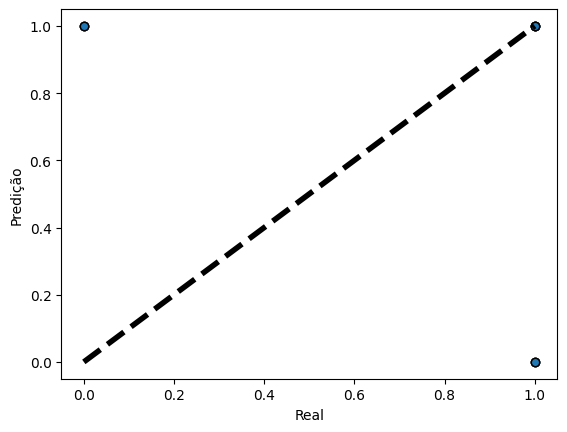

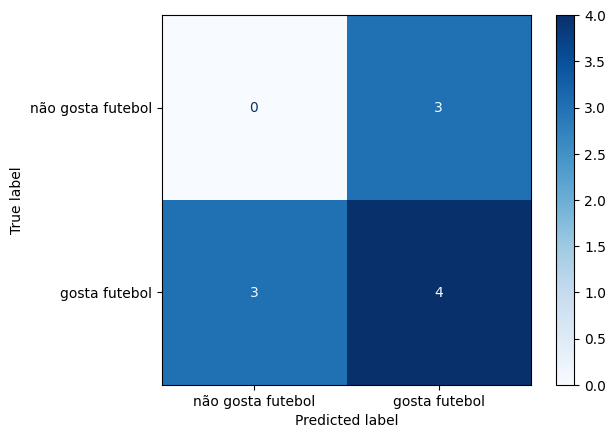

In [ ]:
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_predict
import matplotlib.pyplot as plt

cv_results = cross_val_predict(clf, X_treino, y_treino, cv=3)

print(classification_report(y_treino, cv_results, target_names=categorias_gosta_futebol))

fig, ax = plt.subplots()
ax.scatter(y_treino, cv_results, edgecolors=(0, 0, 0))
ax.plot([y_treino.min(), y_treino.max()], [y_treino.min(), y_treino.max()], 'k--', lw=4)
ax.set_xlabel('Real')
ax.set_ylabel('Predição')
plt.show()

from sklearn.metrics import ConfusionMatrixDisplay

# Em vez de passar o estimador, passamos diretamente as predições da validação cruzada
ConfusionMatrixDisplay.from_predictions(
    y_treino,
    cv_results,
    display_labels=categorias_gosta_futebol,
    cmap=plt.cm.Blues
)
plt.show()

### Otimização do Modelo via Grid Search
Vamos testar diferentes combinações de parâmetros para ver se conseguimos extrair um desempenho melhor dos dados atuais.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Definimos os parâmetros que queremos testar
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Criamos o objeto de busca
grid_search = GridSearchCV(tree.DecisionTreeClassifier(), param_grid, cv=3, scoring='accuracy')
grid_search.fit(X_treino, y_treino)

print(f"Melhores parâmetros encontrados: {grid_search.best_params_}")
print(f"Melhor acurácia média na validação: {grid_search.best_score_:.2f}")

# Atualizando nosso classificador com os melhores parâmetros
clf_otimizado = grid_search.best_estimator_

Melhores parâmetros encontrados: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 5}
Melhor acurácia média na validação: 0.81


Agora, vamos visualizar a nova matriz de confusão do modelo otimizado para comparar.

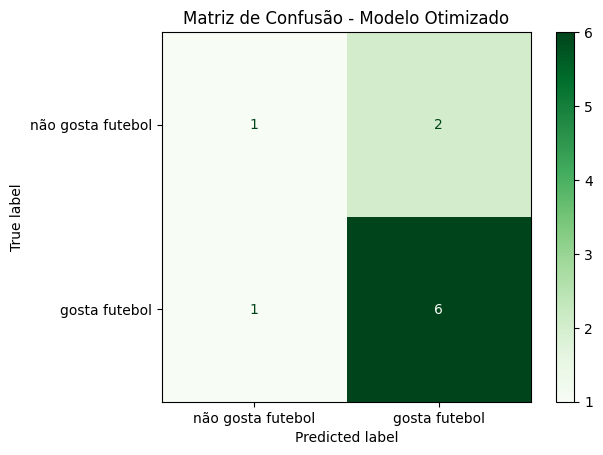

                   precision    recall  f1-score   support

não gosta futebol       0.50      0.33      0.40         3
    gosta futebol       0.75      0.86      0.80         7

         accuracy                           0.70        10
        macro avg       0.62      0.60      0.60        10
     weighted avg       0.68      0.70      0.68        10



In [ ]:
cv_results_opt = cross_val_predict(clf_otimizado, X_treino, y_treino, cv=3)

ConfusionMatrixDisplay.from_predictions(
    y_treino,
    cv_results_opt,
    display_labels=categorias_gosta_futebol,
    cmap=plt.cm.Greens
)
plt.title("Matriz de Confusão - Modelo Otimizado")
plt.show()

print(classification_report(y_treino, cv_results_opt, target_names=categorias_gosta_futebol))

In [ ]:
# Exemplo didatico de uma arvore

df_clientes = pd.read_csv("dados_clientes_nome.csv")

# Treina um algoritmo de árvore de decisão com os dados
from sklearn import tree

atributos = ['idade', 'altura', 'peso', 'sexo', 'gosta de futebol','salario']

X_treino = df_clientes.loc[:, atributos].to_numpy()

y_treino = df_clientes['nacionalidade'].to_numpy()

clf = tree.DecisionTreeClassifier(criterion = "gini", splitter = "best",
                                  max_depth = 5,  min_samples_split = 5,
                                  min_samples_leaf = 2, max_features = 5)
clf = clf.fit(X_treino, y_treino)

import graphviz
dot_data = tree.export_graphviz(clf, out_file=None, filled=True,
                                rounded=True,
                                special_characters=True,
                                feature_names = atributos,
                                class_names=['estrangeiro','brasileiro'])
graph = graphviz.Source(dot_data)
graph.render("nacionalidade_tree")

'nacionalidade_tree.pdf'

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
import pandas as pd
import numpy as np

# Lê o dataset de carros
carros = pd.read_csv("carros_categorical.csv")

carros

,fabricante,modelo,ano,combustivel,hp,cilindros,tipo_transmissao,tracao,num_portas,categoria,tamanho,estilo,km_por_l_estrada,km_por_l_cidade,popularidade,preco_venda,label
0,BMW,1 Series,2011,7,300.0,6.0,3,3,2.0,68,0,4,28,19,3916,40650,65
1,BMW,1 Series,2011,7,300.0,6.0,3,3,2.0,65,0,5,28,20,3916,36350,65
2,BMW,1 Series,2011,7,230.0,6.0,3,3,2.0,68,0,5,28,18,3916,29450,65
3,BMW,1 Series,2011,7,230.0,6.0,3,3,2.0,64,0,4,28,18,3916,34500,65
4,BMW,1 Series,2012,7,230.0,6.0,3,3,2.0,68,0,5,28,18,3916,31200,65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11908,Acura,ZDX,2012,7,300.0,6.0,0,1,4.0,19,2,2,23,16,204,46120,17
11909,Acura,ZDX,2012,7,300.0,6.0,0,1,4.0,19,2,2,23,16,204,56670,17
11910,Acura,ZDX,2012,7,300.0,6.0,0,1,4.0,19,2,2,23,16,204,50620,17
11911,Acura,ZDX,2013,5,300.0,6.0,0,1,4.0,19,2,2,23,16,204,50920,17


In [ ]:
# Seleciona apenas as colunas necessárias
X = carros.loc[:, 'ano':'preco_venda'].to_numpy()

y = carros['label'].to_numpy()

In [ ]:
len(np.unique(y))

927

In [ ]:
# Divide o conjunto em treinamento e teste, na proporção 80-20
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.25,
                                                        random_state=123,
                                                        shuffle=True)

caracteristicas = list(carros.columns[2:-1])

carros['fabricante'] = carros ['fabricante'].astype('category')

categorias = carros['fabricante'].cat.categories

print("Tamanho do conjunto de treinamento: {}".format(len(X_treino)))
print("Tamanho do conjunto de testes: {}".format(len(X_teste)))
print("Quantidade de características: {}".format(len(caracteristicas)))
print("Quantidade de classes ou categorias: {}".format(len(carros ['fabricante'].cat.categories)))

Tamanho do conjunto de treinamento: 8934
Tamanho do conjunto de testes: 2979
Quantidade de características: 14
Quantidade de classes ou categorias: 48


In [ ]:
# Conta a quantidade de categorias de serviço
categ_count = carros['fabricante'].value_counts()
print(str(categ_count))

Chevrolet        1123
Ford              881
Volkswagen        809
Toyota            746
Dodge             626
Nissan            558
GMC               515
Honda             449
Mazda             423
Cadillac          397
Mercedes-Benz     353
Suzuki            351
BMW               333
Infiniti          330
Audi              328
Hyundai           303
Volvo             281
Subaru            256
Acura             252
Kia               231
Mitsubishi        213
Lexus             202
Buick             196
Chrysler          187
Pontiac           186
Lincoln           164
Oldsmobile        150
Land Rover        143
Porsche           136
Saab              111
Aston Martin       93
Plymouth           82
Bentley            74
Ferrari            69
FIAT               62
Scion              60
Maserati           58
Lamborghini        52
Rolls-Royce        31
Lotus              29
Tesla              18
HUMMER             17
Maybach            16
McLaren             5
Alfa Romeo          5
Spyker    

<AxesSubplot:>

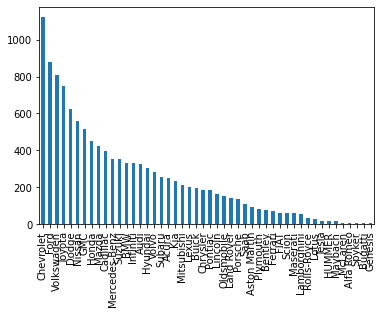

In [ ]:
categ_count.plot.bar()

In [ ]:
carros.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11913 entries, 0 to 11912
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   fabricante        11913 non-null  category
 1   modelo            11913 non-null  object  
 2   ano               11913 non-null  int64   
 3   combustivel       11913 non-null  int64   
 4   hp                11913 non-null  float64 
 5   cilindros         11913 non-null  float64 
 6   tipo_transmissao  11913 non-null  int64   
 7   tracao            11913 non-null  int64   
 8   num_portas        11913 non-null  float64 
 9   categoria         11913 non-null  int64   
 10  tamanho           11913 non-null  int64   
 11  estilo            11913 non-null  int64   
 12  km_por_l_estrada  11913 non-null  int64   
 13  km_por_l_cidade   11913 non-null  int64   
 14  popularidade      11913 non-null  int64   
 15  preco_venda       11913 non-null  int64   
 16  label             1191

In [ ]:
# Treina um algoritmo de árvore de decisão com os dados
from sklearn import tree

clf = tree.DecisionTreeClassifier(criterion = "gini", splitter = "best",
                                  max_depth = 3,  min_samples_split = 5,
                                  min_samples_leaf = 2, max_features = 2)

clf_gini_best = clf.fit(X_treino, y_treino)

In [ ]:
# Avalia o desempenho do modelo treinado
import numpy as np
from sklearn.metrics import classification_report

y_pred = clf_gini_best.predict(X_teste)


In [ ]:
from sklearn.model_selection import cross_val_predict
import matplotlib.pyplot as plt

from sklearn.metrics import plot_confusion_matrix

plot_confusion_matrix(clf_gini_best, X_teste, y_teste,
                                 display_labels=categorias_gosta_futebol,
                                 cmap=plt.cm.Blues,
                                 normalize=None)

fig, ax = plt.subplots()
ax.scatter(y, cv_results, edgecolors=(0, 0, 0))
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=4)
ax.set_xlabel('Real')
ax.set_ylabel('Predição')
plt.show()